In [ ]:
from google.colab import files
uploaded = files.upload()

Saving METABRIC_RNA_nomut.csv to METABRIC_RNA_nomut.csv


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import io
df = pd.read_csv(io.StringIO(uploaded['METABRIC_RNA_nomut.csv'].decode('utf-8')))

In [ ]:
df.info()
df.columns
len(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 520 entries, patient_id to ugt2b7
dtypes: float64(496), int64(7), object(17)
memory usage: 7.6+ MB


1904

In [ ]:
# elist = [df.columns[678], df.columns[688], df.columns[690], df.columns[692]]
# for name in elist:
#   df[name] = df[name].astype(str)
#   print(df[name].unique())

In [ ]:
for i in range(df.shape[1]):
  if (df[df.columns[i]].dtype == "object"):
    df[df.columns[i]] = df[df.columns[i]].str.upper().str.strip()


In [ ]:
for i in range(df.shape[1]):
  print(df.columns[i])
  print(df[df.columns[i]].unique())
  print()

patient_id
[   0    2    5 ... 7297 7298 7299]

age_at_diagnosis
[75.65 43.19 48.87 ... 43.1  42.88 60.02]

type_of_breast_surgery
['MASTECTOMY' 'BREAST CONSERVING' nan]

cancer_type
['BREAST CANCER' 'BREAST SARCOMA']

cancer_type_detailed
['BREAST INVASIVE DUCTAL CARCINOMA'
 'BREAST MIXED DUCTAL AND LOBULAR CARCINOMA'
 'BREAST INVASIVE LOBULAR CARCINOMA'
 'BREAST INVASIVE MIXED MUCINOUS CARCINOMA' 'BREAST' nan
 'METAPLASTIC BREAST CANCER']

cellularity
[nan 'HIGH' 'MODERATE' 'LOW']

chemotherapy
[0 1]

pam50_+_claudin-low_subtype
['CLAUDIN-LOW' 'LUMA' 'LUMB' 'HER2' 'NORMAL' 'BASAL' 'NC']

cohort
[1 2 3 5 4]

er_status_measured_by_ihc
['POSITVE' 'NEGATIVE' nan]

er_status
['POSITIVE' 'NEGATIVE']

neoplasm_histologic_grade
[ 3.  2.  1. nan]

her2_status_measured_by_snp6
['NEUTRAL' 'LOSS' 'GAIN' 'UNDEF']

her2_status
['NEGATIVE' 'POSITIVE']

tumor_other_histologic_subtype
['DUCTAL/NST' 'MIXED' 'LOBULAR' 'TUBULAR/ CRIBRIFORM' 'MUCINOUS'
 'MEDULLARY' 'OTHER' nan 'METAPLASTIC']

hormone_the

In [ ]:
# check for NaN in ROWS
count = 0
n_rows = len(df)
for i in range(n_rows):
  for item in df.iloc[i]:
    if pd.isna(item):
      count += 1
      print(i, df.iloc[i])
      break
print("\n\n other isna check")
print(df[df.isna().any(axis=1)])
print(count)
print(count/n_rows)

Streaming output truncated to the last 5000 lines.
cancer_type                                  BREAST CANCER
cancer_type_detailed      BREAST INVASIVE DUCTAL CARCINOMA
                                        ...               
tnk2                                                1.2364
tulp4                                               1.2358
ugt2b15                                            -0.4772
ugt2b17                                            -0.1815
ugt2b7                                             -0.6851
Name: 1374, Length: 520, dtype: object
1381 patient_id                                             5463
age_at_diagnosis                                      71.91
type_of_breast_surgery                           MASTECTOMY
cancer_type                                   BREAST CANCER
cancer_type_detailed      BREAST INVASIVE LOBULAR CARCINOMA
                                        ...                
tnk2                                                 2.3383
tulp4        

In [ ]:
# only ordinal is cellularity.
df['cellularity'] = df['cellularity'].map({'LOW': 1, 'MODERATE': 2, 'HIGH': 3}).fillna(df['cellularity'].map({'LOW': 1, 'MODERATE': 2, 'HIGH': 3}).median())

In [ ]:
# numerical
for i in range(df.shape[1]):
  if df[df.columns[i]].dtype != "object":
    df[df.columns[i]] = df[df.columns[i]].fillna(df[df.columns[i]].median())
print(df.isna().sum())

patient_id                 0
age_at_diagnosis           0
type_of_breast_surgery    22
cancer_type                0
cancer_type_detailed      15
                          ..
tnk2                       0
tulp4                      0
ugt2b15                    0
ugt2b17                    0
ugt2b7                     0
Length: 520, dtype: int64


In [ ]:
# nominal
df = pd.get_dummies(df, columns=df.select_dtypes(include=['object']).columns, dummy_na=True, dtype=int)
print(df)

      patient_id  age_at_diagnosis  cellularity  chemotherapy  cohort  \
0              0             75.65          3.0             0       1   
1              2             43.19          3.0             0       1   
2              5             48.87          3.0             1       1   
3              6             47.68          2.0             1       1   
4              8             76.97          3.0             1       1   
...          ...               ...          ...           ...     ...   
1899        7295             43.10          3.0             0       4   
1900        7296             42.88          3.0             0       4   
1901        7297             62.90          3.0             0       4   
1902        7298             61.16          2.0             0       4   
1903        7299             60.02          3.0             0       4   

      neoplasm_histologic_grade  hormone_therapy  \
0                           3.0                1   
1                  

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print(df.shape)
print(df.columns)

(1904, 585)
Index(['patient_id', 'age_at_diagnosis', 'cellularity', 'chemotherapy',
       'cohort', 'neoplasm_histologic_grade', 'hormone_therapy',
       'lymph_nodes_examined_positive', 'mutation_count',
       'nottingham_prognostic_index',
       ...
       'pr_status_nan', '3-gene_classifier_subtype_ER+/HER2- HIGH PROLIF',
       '3-gene_classifier_subtype_ER+/HER2- LOW PROLIF',
       '3-gene_classifier_subtype_ER-/HER2-',
       '3-gene_classifier_subtype_HER2+', '3-gene_classifier_subtype_nan',
       'death_from_cancer_DIED OF DISEASE',
       'death_from_cancer_DIED OF OTHER CAUSES', 'death_from_cancer_LIVING',
       'death_from_cancer_nan'],
      dtype='object', length=585)


given that person has died, what is survival time? based off of factors
remove "death of" and y value is survival time in years (change overall months to years)

 - remove survival rates from db (eg
 - tr/val/test

In [ ]:
main_df = df[df['overall_survival'] == 0].copy()   # don't include censored data
print(main_df)
print(main_df['overall_survival'])

      patient_id  age_at_diagnosis  cellularity  chemotherapy  cohort  \
2              5             48.87          3.0             1       1   
4              8             76.97          3.0             1       1   
5             10             78.77          2.0             0       1   
7             22             89.08          2.0             0       1   
8             28             86.41          2.0             0       1   
...          ...               ...          ...           ...     ...   
1898        7294             59.20          3.0             0       4   
1900        7296             42.88          3.0             0       4   
1901        7297             62.90          3.0             0       4   
1902        7298             61.16          2.0             0       4   
1903        7299             60.02          3.0             0       4   

      neoplasm_histologic_grade  hormone_therapy  \
2                           2.0                1   
4                  

In [ ]:
drop_cols = ['overall_survival', 'cohort', 'nottingham_prognostic_index']
drop_cols += [c for c in main_df.columns if c.startswith('death_from_cancer_')]
main_df = main_df.drop(columns=drop_cols, errors='ignore')

In [ ]:
main_df = main_df.reset_index(drop=True)
display(main_df.head())

,patient_id,age_at_diagnosis,cellularity,chemotherapy,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,overall_survival_months,radio_therapy,...,oncotree_code_MDLC,oncotree_code_nan,pr_status_NEGATIVE,pr_status_POSITIVE,pr_status_nan,3-gene_classifier_subtype_ER+/HER2- HIGH PROLIF,3-gene_classifier_subtype_ER+/HER2- LOW PROLIF,3-gene_classifier_subtype_ER-/HER2-,3-gene_classifier_subtype_HER2+,3-gene_classifier_subtype_nan
0,5,48.87,3.0,1,2.0,1,1,2.0,163.700000,0,...,0,0,0,1,0,0,0,0,0,1
1,8,76.97,3.0,1,3.0,1,8,2.0,41.366667,1,...,1,0,0,1,0,1,0,0,0,0
2,10,78.77,2.0,0,3.0,1,0,4.0,7.800000,1,...,0,0,0,1,0,1,0,0,0,0
3,22,89.08,2.0,0,2.0,1,1,1.0,99.533333,1,...,1,0,1,0,0,0,0,0,0,1
4,28,86.41,2.0,0,3.0,1,1,4.0,36.566667,1,...,0,0,1,0,0,1,0,0,0,0


In [ ]:
# patient id dict (row:patient_id)
print(main_df['patient_id'])

num_rows = len(main_df)
id_dict = {}
for i in range(num_rows):
  id_dict[i] = main_df.iloc[i]['patient_id']
print(id_dict)
main_df.drop(columns=['patient_id'], inplace=True)

0          5
1          8
2         10
3         22
4         28
        ... 
1098    7294
1099    7296
1100    7297
1101    7298
1102    7299
Name: patient_id, Length: 1103, dtype: int64
{0: np.float64(5.0), 1: np.float64(8.0), 2: np.float64(10.0), 3: np.float64(22.0), 4: np.float64(28.0), 5: np.float64(35.0), 6: np.float64(36.0), 7: np.float64(46.0), 8: np.float64(79.0), 9: np.float64(83.0), 10: np.float64(95.0), 11: np.float64(100.0), 12: np.float64(102.0), 13: np.float64(108.0), 14: np.float64(109.0), 15: np.float64(112.0), 16: np.float64(115.0), 17: np.float64(119.0), 18: np.float64(120.0), 19: np.float64(123.0), 20: np.float64(129.0), 21: np.float64(131.0), 22: np.float64(134.0), 23: np.float64(143.0), 24: np.float64(144.0), 25: np.float64(146.0), 26: np.float64(147.0), 27: np.float64(149.0), 28: np.float64(151.0), 29: np.float64(163.0), 30: np.float64(165.0), 31: np.float64(167.0), 32: np.float64(170.0), 33: np.float64(177.0), 34: np.float64(178.0), 35: np.float64(179.0), 36: np

In [ ]:
main_df.loc[:, 'time_until_death'] = main_df.loc[:, 'overall_survival_months']/12
main_df.drop(columns=['overall_survival_months'], inplace=True)
print(main_df['time_until_death'])

0       13.641667
1        3.447222
2        0.650000
3        8.294444
4        3.047222
          ...    
1098     6.894444
1099     3.727778
1100    14.663889
1101     7.186111
1102    16.825000
Name: time_until_death, Length: 1103, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

pids = main_df.index.values
y_target = main_df['time_until_death']

train_pids, temp_pids, _, _ = train_test_split(
    pids, y_target, test_size=0.30, random_state=42
)

val_pids, test_pids, _, _ = train_test_split(
    temp_pids, y_target.loc[temp_pids], test_size=0.5, random_state=43
)

main_train = main_df[main_df.index.isin(train_pids)].copy()
main_val = main_df[main_df.index.isin(val_pids)].copy()
main_test = main_df[main_df.index.isin(test_pids)].copy()

print(f"Training set shape: {main_train.shape}")
print(f"Validation set shape: {main_val.shape}")
print(f"Test set shape: {main_test.shape}")

print(main_train)
print(main_val)
print(main_test)

Training set shape: (772, 577)
Validation set shape: (165, 577)
Test set shape: (166, 577)
      age_at_diagnosis  cellularity  chemotherapy  neoplasm_histologic_grade  \
0                48.87          3.0             1                        2.0   
1                76.97          3.0             1                        3.0   
4                86.41          2.0             0                        3.0   
5                84.22          3.0             0                        2.0   
7                83.02          3.0             0                        3.0   
...                ...          ...           ...                        ...   
1097             52.90          3.0             0                        2.0   
1099             42.88          3.0             0                        3.0   
1100             62.90          3.0             0                        3.0   
1101             61.16          2.0             0                        2.0   
1102             60.02       

In [ ]:
X_train = main_train.drop(columns=['time_until_death'])
y_train = main_train['time_until_death']

X_val = main_val.drop(columns=['time_until_death'])
y_val = main_val['time_until_death']

X_test = main_test.drop(columns=['time_until_death'])
y_test = main_test['time_until_death']

LIN REG BELOW

 - try regularizing to reduce coefficients since a lot is noise

Best parameters: {'alpha': 10, 'l1_ratio': 0.0}
m = [-6.65917034e-03  7.17958455e-03 -2.51917602e-02 -9.46381229e-03
 -3.83128825e-03 -1.25969295e-01  3.81423849e-02  7.52986182e-03
 -4.32759938e-02 -3.10243433e-02 -9.08484810e-03 -1.78648249e-03
 -8.26087558e-04  2.02537956e-02 -1.02796622e-02  5.30719416e-03
 -1.00496336e-02 -2.21414753e-02  2.35620105e-02  1.09265718e-02
  1.20941173e-02 -1.16067386e-02 -2.61020067e-03 -2.74921199e-02
 -8.30753523e-03  2.02004426e-02 -3.15487795e-02 -1.61167098e-02
  9.63488026e-03 -1.45716784e-03 -4.11878754e-02 -8.73942599e-03
 -8.54938927e-03 -2.49751419e-02 -2.39734514e-02 -3.71093910e-02
 -3.25902061e-02 -2.22843215e-02 -1.84255273e-02  1.47432884e-02
 -1.75328405e-02 -2.36307796e-02  2.29875671e-02 -1.99436530e-02
 -2.45675144e-02 -3.42031438e-02 -2.26401354e-02 -1.37412764e-03
  5.67468680e-03 -1.48944196e-02 -3.13809866e-02 -3.39002629e-02
 -2.45399698e-02  5.19136651e-03 -1.99305809e-02 -5.29668043e-02
 -5.37436758e-03 -1.81562517e-02  2.46

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.086e+04, tolerance: 2.750e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


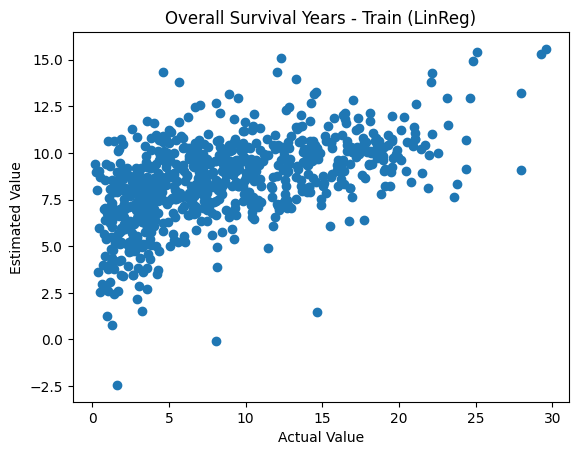


Validation (LinReg) set:
pearson = 0.41311923457762195
r2 = 0.1505187012598388
mse = 22.904540175193436


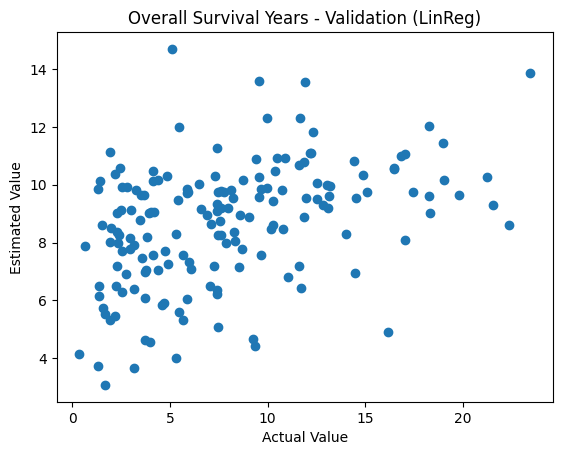


Test (LinReg) set:
pearson = 0.3807195722895218
r2 = 0.14454712152077975
mse = 26.230475351475445


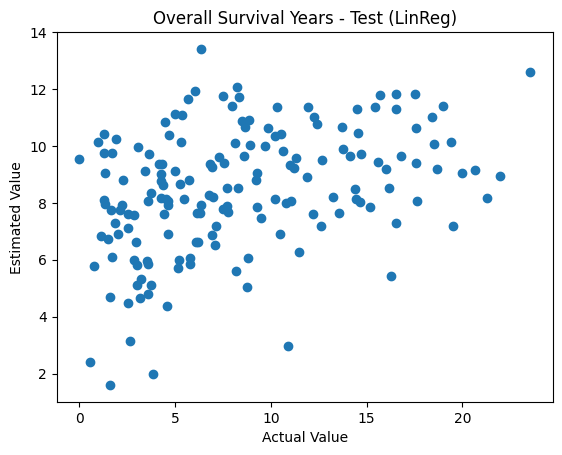

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

elastic_net = ElasticNet()

param_grid = {
    'alpha': [0.1, 1, 10],
    'l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0],
}

grid = GridSearchCV(elastic_net, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
lr = grid.best_estimator_

m = lr.coef_.ravel()
b = lr.intercept_

print(f"m = {m}")
print(f"sorted m = {np.sort(m)}")
print(f"b = {b}")

def evaluate_split(name, model, X, y_true):
    y_pred = model.predict(X)

    pearson, _ = stats.pearsonr(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    print(f"{name} set:")
    print(f"pearson = {pearson}")
    print(f"r2 = {r2}")
    print(f"mse = {mse}")

    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.xlabel("Actual Value")
    plt.ylabel("Estimated Value")
    plt.title(f"Overall Survival Years - {name}")
    plt.show()

    print()

    return y_pred, pearson, r2

y_train_pred, train_pearson, train_r2 = evaluate_split("Train (LinReg)", lr, X_train, y_train)
y_val_pred, val_pearson, val_r2 = evaluate_split("Validation (LinReg)", lr, X_val,  y_val)
y_test_pred, test_pearson, test_r2  = evaluate_split("Test (LinReg)", lr, X_test,  y_test)

In [ ]:
def bootstrap_metric_ci(X, y, model, metric_fn, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    n = len(y)
    stats_boot = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        X_b = X.iloc[idx]
        y_b = y.iloc[idx]

        y_pred_b = model.predict(X_b)
        stats_boot.append(metric_fn(y_b, y_pred_b))

    stats_boot = np.array(stats_boot)
    mean = stats_boot.mean()
    lower = np.percentile(stats_boot, 2.5)
    upper = np.percentile(stats_boot, 97.5)
    return mean, lower, upper

def pearson_metric(y_true, y_pred):
    r, _ = stats.pearsonr(y_true, y_pred)
    return r

def r2_metric(y_true, y_pred):
    return r2_score(y_true, y_pred)

def mse_metric(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

pearson_mean, pearson_lo, pearson_hi = bootstrap_metric_ci(
    X_test, y_test, lr, pearson_metric, n_bootstrap=2000
)

r2_mean, r2_lo, r2_hi = bootstrap_metric_ci(
    X_test, y_test, lr, r2_metric, n_bootstrap=2000
)

mse_mean, mse_lo, mse_hi = bootstrap_metric_ci(
    X_test, y_test, lr, mse_metric, n_bootstrap=2000
)

print("Test Pearson:")
print(f"mean = {pearson_mean:.3f}")
print(f"95% CI = [{pearson_lo:.3f}, {pearson_hi:.3f}]") # Corrected from 5% CI to 95% CI
print()
print("Test r2:")
print(f"mean = {r2_mean:.3f}")
print(f"95% CI = [{r2_lo:.3f}, {r2_hi:.3f}]")
print()
print("Test mse:")
print(f"mse = {mse_mean:.3f}")
print(f"95% CI = [{mse_lo:.3f}, {mse_hi:.3f}]")

Test Pearson:
mean = 0.379
95% CI = [0.262, 0.492]

Test r2:
mean = 0.138
95% CI = [0.043, 0.227]

Test mse:
mse = 26.187
95% CI = [21.222, 31.540]



Top 20 Linear Regression Coefficients:

lymph_nodes_examined_positive: -0.1260
hsd17b14: 0.0584
aurka: -0.0572
mapk14: -0.0547
e2f8: -0.0530
mapt: 0.0529
hsd3b7: 0.0506
ctcf: -0.0501
mapk6: -0.0480
diras3: 0.0474
vegfa: -0.0470
cxcr1: -0.0462
ep300: -0.0458
cbfb: -0.0455
mapk9: -0.0451
nf2: -0.0450
igf1r: 0.0435
tumor_size: -0.0433
shbg: 0.0430
dll4: -0.0421




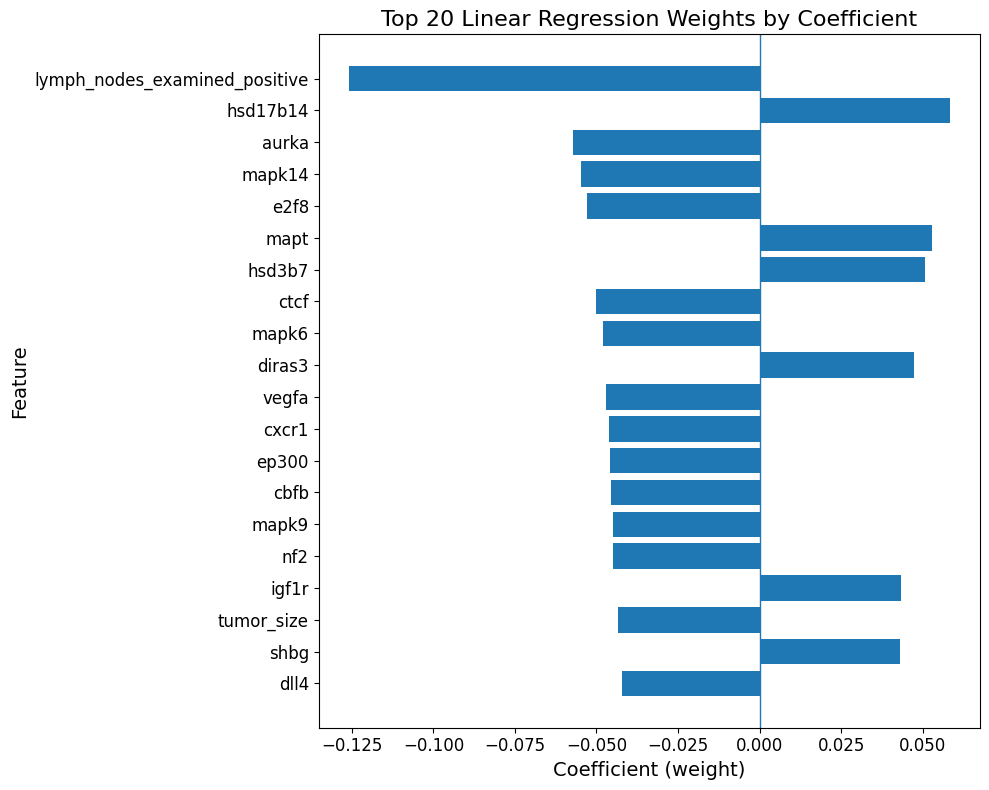

In [ ]:
coefs = lr.coef_.ravel()
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
})

coef_df['abs_coef'] = coef_df['coef'].abs()

top_n = 20
top = coef_df.sort_values('abs_coef', ascending=False).head(top_n)

print(f"\nTop {top_n} Linear Regression Coefficients:\n")
for index, row in top.iterrows():
    print(f"{row['feature']}: {row['coef']:.4f}")
print("\n")

plt.figure(figsize=(10, 8)) # Adjusted figure size

plt.barh(top['feature'][::-1], top['coef'][::-1])
plt.axvline(0, linewidth=1)

plt.xlabel("Coefficient (weight)", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title(f"Top {top_n} Linear Regression Weights by Coefficient", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

FOREST BELOW

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import randint

param_dist = {
  'n_estimators': randint(100, 500),
  'max_depth': randint(3, 15),
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5)
}

rf_reg = RandomForestRegressor()

rand_search = RandomizedSearchCV(
  rf_reg, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='neg_mean_squared_error',
  n_jobs=-1, random_state=42
)

rand_search.fit(X_train, y_train)
rf = rand_search.best_estimator_

y_pred = rf.predict(X_val)
pearson, _ = stats.pearsonr(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)

print(f"pearson = {pearson}")
print(f"r2 = {r2}")
print(f"mse = {mse}")

pearson = 0.43088785809317964
r2 = 0.16042562953651007
mse = 22.637419948930294


Train (Random Forest) set:
pearson = 0.9634006274059208
r2 = 0.8253521557704334
mse = 6.220575377484804


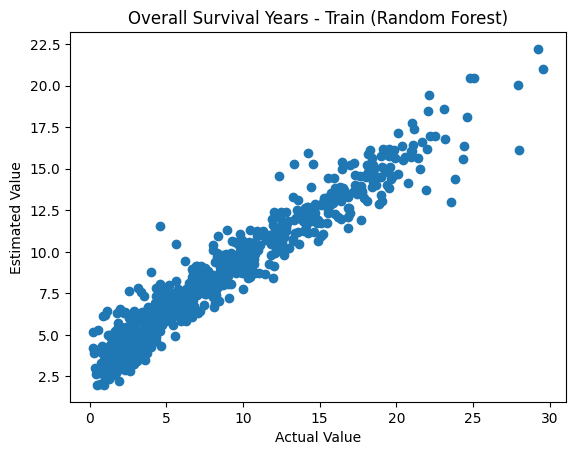


Validation (Random Forest) set:
pearson = 0.43088785809317964
r2 = 0.16042562953651007
mse = 22.637419948930294


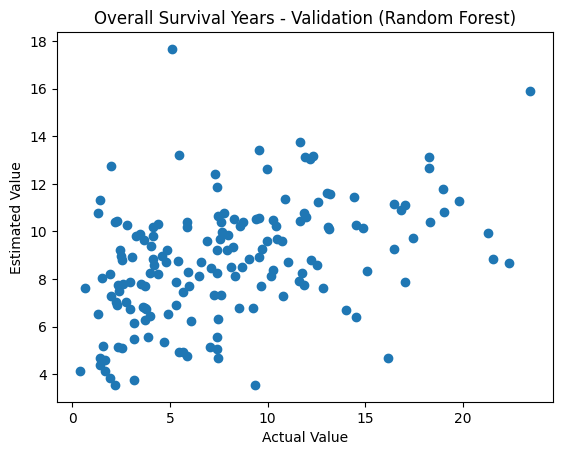


Test (Random Forest) set:
pearson = 0.3827043635683404
r2 = 0.1453924025640836
mse = 26.204556771821043


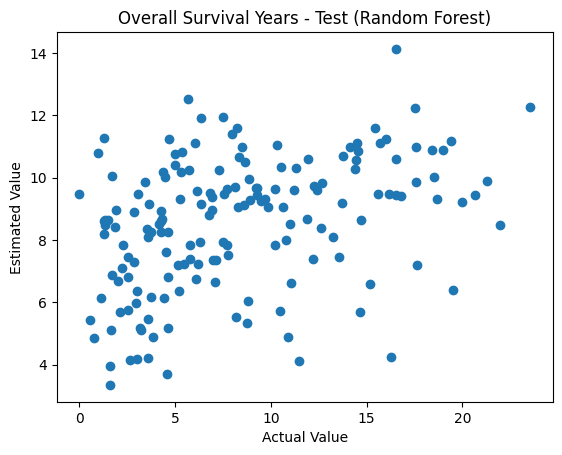

In [ ]:
y_train_pred_rf, train_pearson_rf, train_r2_rf = evaluate_split("Train (Random Forest)", rf, X_train, y_train)
y_val_pred_rf, val_pearson_rf, val_r2_rf = evaluate_split("Validation (Random Forest)", rf, X_val, y_val)
y_test_pred_rf, test_pearson_rf, test_r2_rf = evaluate_split("Test (Random Forest)", rf, X_test, y_test)

In [ ]:
pearson_mean, pearson_lo, pearson_hi = bootstrap_metric_ci(
    X_test, y_test, rf, pearson_metric, n_bootstrap=2000
)

r2_mean, r2_lo, r2_hi = bootstrap_metric_ci(
    X_test, y_test, rf, r2_metric, n_bootstrap=2000
)

mse_mean, mse_lo, mse_hi = bootstrap_metric_ci(
    X_test, y_test, rf, mse_metric, n_bootstrap=2000
)

print("Test Pearson (RF):")
print(f"mean = {pearson_mean:.3f}")
print(f"95% CI = [{pearson_lo:.3f}, {pearson_hi:.3f}]")
print()
print("Test r2 (RF):")
print(f"mean = {r2_mean:.3f}")
print(f"95% CI = [{r2_lo:.3f}, {r2_hi:.3f}]")
print()
print("Test mse (RF):")
print(f"mse = {mse_mean:.3f}")
print(f"95% CI = [{mse_lo:.3f}, {mse_hi:.3f}]")

Test Pearson (RF):
mean = 0.381
95% CI = [0.245, 0.512]

Test r2 (RF):
mean = 0.138
95% CI = [0.031, 0.238]

Test mse (RF):
mse = 26.167
95% CI = [21.061, 31.405]



Top 20 Random Forest Feature Importances:

chek1: 0.0326
mapt: 0.0307
lymph_nodes_examined_positive: 0.0266
aurka: 0.0238
chemotherapy: 0.0216
mapk6: 0.0181
mapk14: 0.0147
dtx3: 0.0137
tumor_size: 0.0110
pdpk1: 0.0105
cxcr1: 0.0082
rb1: 0.0075
bcl2: 0.0075
shbg: 0.0072
igf1r: 0.0072
cyp21a2: 0.0065
mlh1: 0.0063
hsd17b14: 0.0058
nf2: 0.0057
diras3: 0.0055




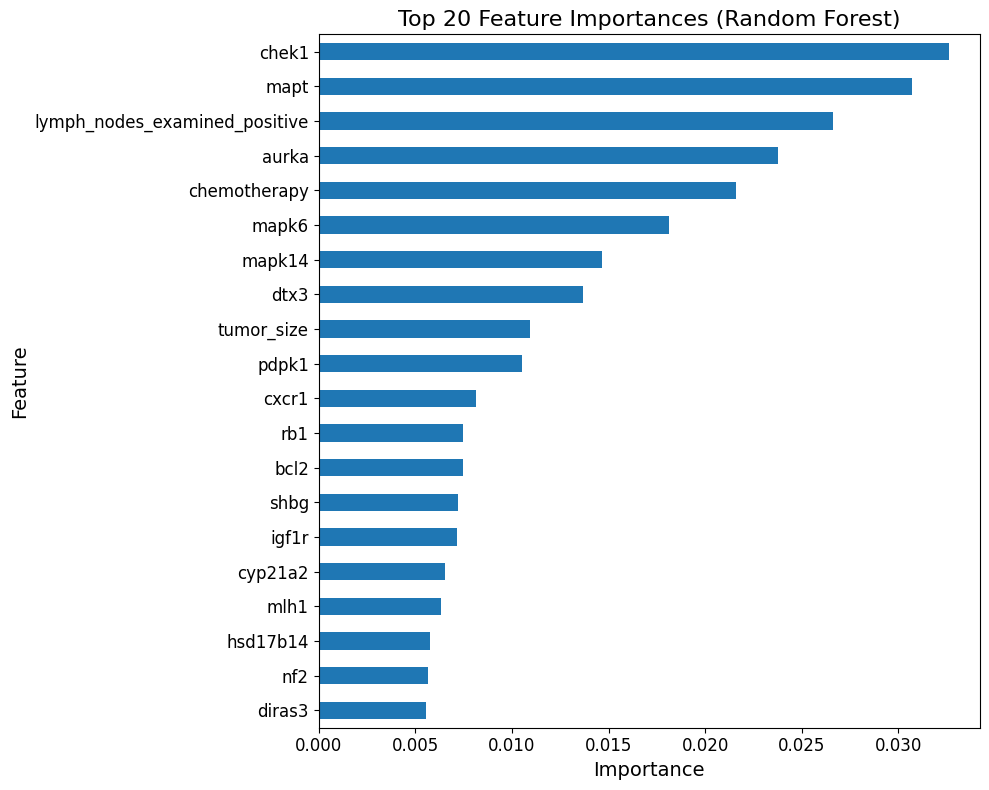

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

top_n = 20

print(f"\nTop {top_n} Random Forest Feature Importances:\n")
for feature, importance in importances.head(top_n).items():
    print(f"{feature}: {importance:.4f}")
print("\n")

plt.figure(figsize=(10, 8))
importances.head(top_n).plot(kind='barh')
plt.title(f"Top {top_n} Feature Importances (Random Forest)", fontsize=16)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

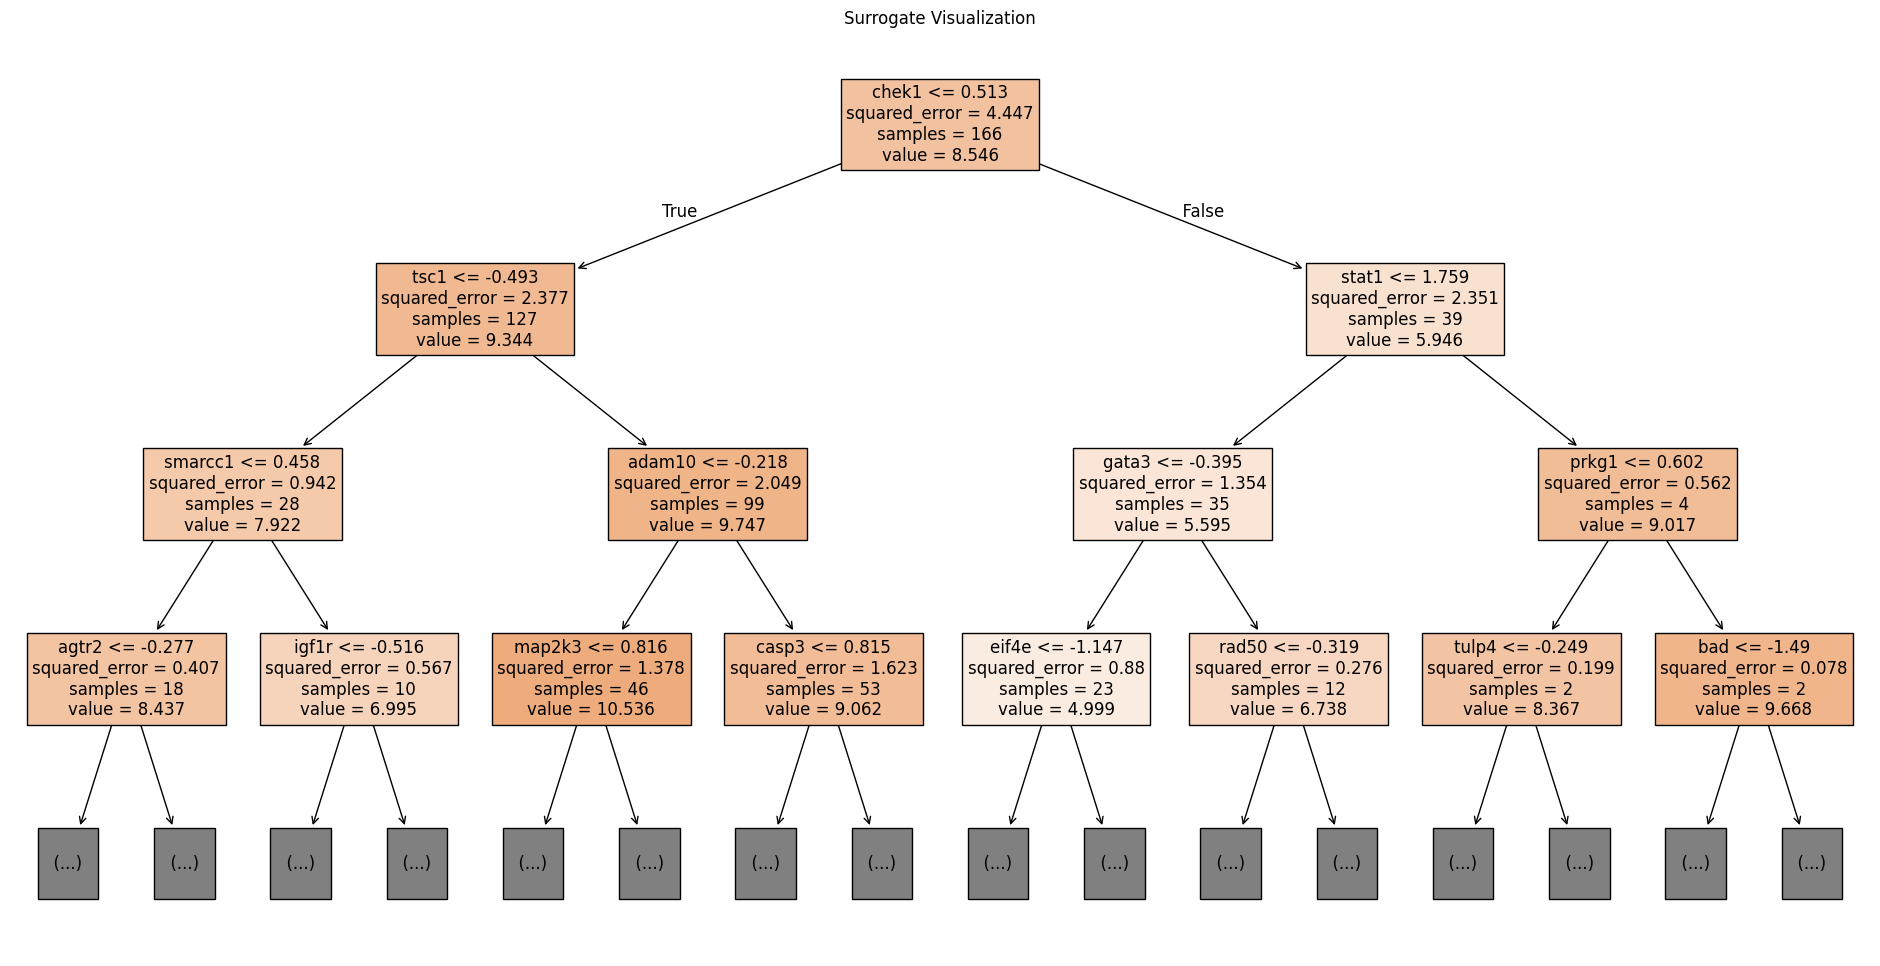

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

test_preds = rf.predict(X_test)

surrogate = DecisionTreeRegressor(random_state=42)
surrogate.fit(X_test, test_preds)

def wrap_name(name, width=12):
    return "\n".join([name[i:i+width] for i in range(0, len(name), width)])

pretty_features = [wrap_name(f) for f in X_test.columns]

plt.figure(figsize=(24, 12))
plot_tree(
    surrogate,
    feature_names=pretty_features,
    filled=True,
    max_depth=3,
    fontsize=12,
)

plt.title("Surrogate Visualization")
plt.show()